# EDA — CDC Diabetes Health Indicators (BRFSS 2015)
**Projet PFA — Dataset comportemental & habitudes de vie**

253 680 répondants · 21 features · Source : CDC / Kaggle

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
os.makedirs('../../../data/processed', exist_ok=True)

print('Librairies chargées.')

Librairies chargées.


---
## Section 1 — Chargement et aperçu

In [2]:
df = pd.read_csv('../../../data/raw/cdc_diabetes.csv')

print('=== SHAPE ===')
print(f'{df.shape[0]:,} lignes × {df.shape[1]} colonnes\n')

print('=== TYPES ===')
print(df.dtypes)
print()

print('=== VALEURS MANQUANTES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Aucune valeur manquante ✓')

=== SHAPE ===
253,680 lignes × 22 colonnes

=== TYPES ===
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

=== VALEURS MANQUANTES ===
Aucune valeur manquante ✓


In [3]:
print('=== STATISTIQUES DESCRIPTIVES ===')
df.describe().round(2)

=== STATISTIQUES DESCRIPTIVES ===


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.14,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,...,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.35,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,...,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.00,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.00,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.00,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,...,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,1.00,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


In [4]:
print('=== 5 PREMIÈRES LIGNES ===')
df.head()

=== 5 PREMIÈRES LIGNES ===


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


---
## Section 2 — Habitudes de vie : diabétiques vs non-diabétiques

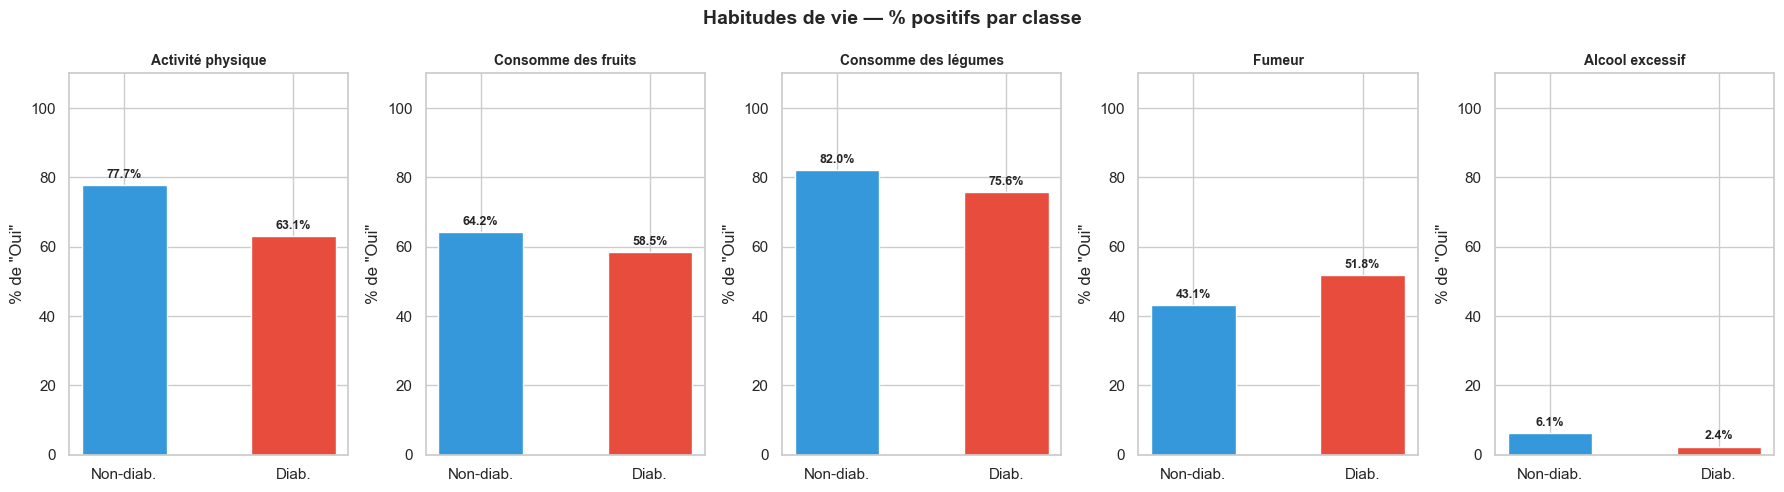


=== DIFFÉRENCES ENTRE CLASSES (en points de %) ===
  Activité physique              : -14.6pp  ↓ moins chez diabétiques
  Consomme des fruits            : -5.7pp  ↓ moins chez diabétiques
  Consomme des légumes           : -6.4pp  ↓ moins chez diabétiques
  Fumeur                         : +8.7pp  ↑ plus chez diabétiques
  Alcool excessif                : -3.8pp  ↓ moins chez diabétiques


In [5]:
lifestyle_features = {
    'PhysActivity':       'Activité physique',
    'Fruits':             'Consomme des fruits',
    'Veggies':            'Consomme des légumes',
    'Smoker':             'Fumeur',
    'HvyAlcoholConsump':  'Alcool excessif'
}

colors = {'Non-diabétique': '#3498db', 'Diabétique': '#e74c3c'}

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, (col, label) in zip(axes, lifestyle_features.items()):
    rates = df.groupby('Diabetes_binary')[col].mean() * 100
    bars = ax.bar(
        ['Non-diab.', 'Diab.'],
        rates.values,
        color=['#3498db', '#e74c3c'],
        width=0.5,
        edgecolor='white'
    )
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9, fontweight='bold')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('% de "Oui"')
    ax.set_ylim(0, 110)

fig.suptitle('Habitudes de vie — % positifs par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../../data/processed/lifestyle_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== DIFFÉRENCES ENTRE CLASSES (en points de %) ===')
for col, label in lifestyle_features.items():
    rates = df.groupby('Diabetes_binary')[col].mean() * 100
    diff = rates[1] - rates[0]
    direction = '↑ plus chez diabétiques' if diff > 0 else '↓ moins chez diabétiques'
    print(f'  {label:<30} : {diff:+.1f}pp  {direction}')

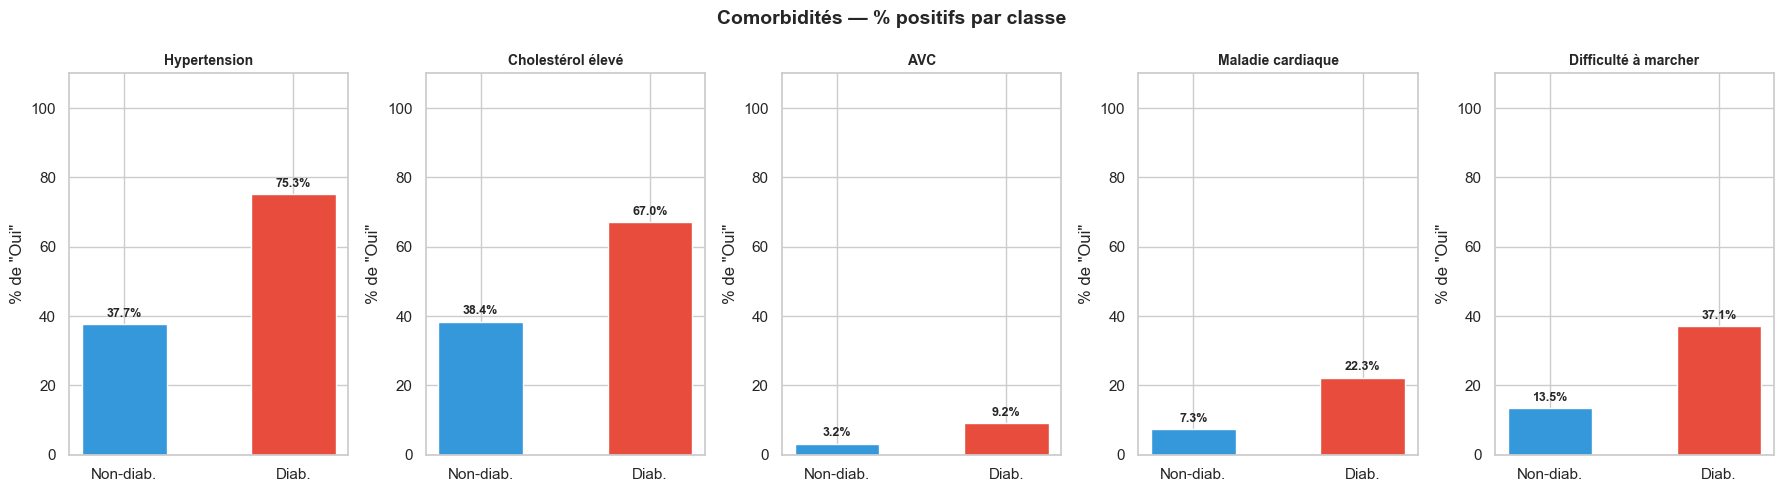

In [6]:
# Features binaires supplémentaires : HighBP, HighChol, Stroke, HeartDiseaseorAttack, DiffWalk
health_features = {
    'HighBP':               'Hypertension',
    'HighChol':             'Cholestérol élevé',
    'Stroke':               'AVC',
    'HeartDiseaseorAttack': 'Maladie cardiaque',
    'DiffWalk':             'Difficulté à marcher'
}

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, (col, label) in zip(axes, health_features.items()):
    rates = df.groupby('Diabetes_binary')[col].mean() * 100
    bars = ax.bar(
        ['Non-diab.', 'Diab.'],
        rates.values,
        color=['#3498db', '#e74c3c'],
        width=0.5,
        edgecolor='white'
    )
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9, fontweight='bold')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('% de "Oui"')
    ax.set_ylim(0, 110)

fig.suptitle('Comorbidités — % positifs par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — Corrélations avec le diabète

In [7]:
# Top 10 features corrélées avec Diabetes_binary
corr_with_target = df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)

print('=== TOP 10 FEATURES CORRÉLÉES AU DIABÈTE ===')
print(corr_with_target.head(10).round(3).to_string())
print('\n=== TOP 5 CORRÉLATIONS NÉGATIVES ===')
print(corr_with_target.tail(5).round(3).to_string())

=== TOP 10 FEATURES CORRÉLÉES AU DIABÈTE ===
GenHlth                 0.294
HighBP                  0.263
DiffWalk                0.218
BMI                     0.217
HighChol                0.200
Age                     0.177
HeartDiseaseorAttack    0.177
PhysHlth                0.171
Stroke                  0.106
MentHlth                0.069

=== TOP 5 CORRÉLATIONS NÉGATIVES ===
Veggies             -0.057
HvyAlcoholConsump   -0.057
PhysActivity        -0.118
Education           -0.124
Income              -0.164


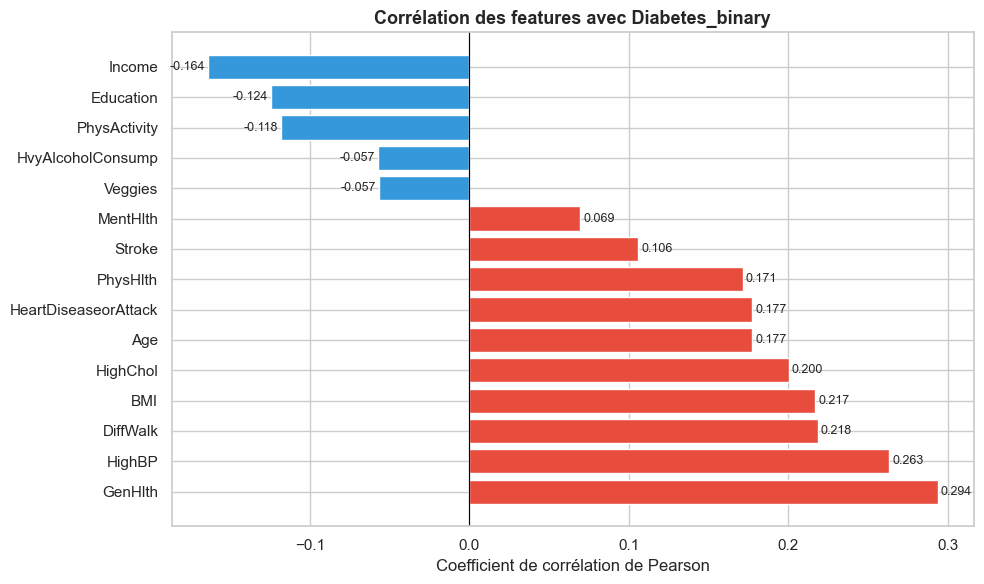

In [8]:
# Bar chart des corrélations
top10 = corr_with_target.head(10)
bottom5 = corr_with_target.tail(5)
combined = pd.concat([top10, bottom5]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in combined.values]
bars = ax.barh(combined.index, combined.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélation des features avec Diabetes_binary', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient de corrélation de Pearson')
for bar, val in zip(bars, combined.values):
    ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

Heatmap sauvegardée → data/processed/correlation_heatmap_cdc.png


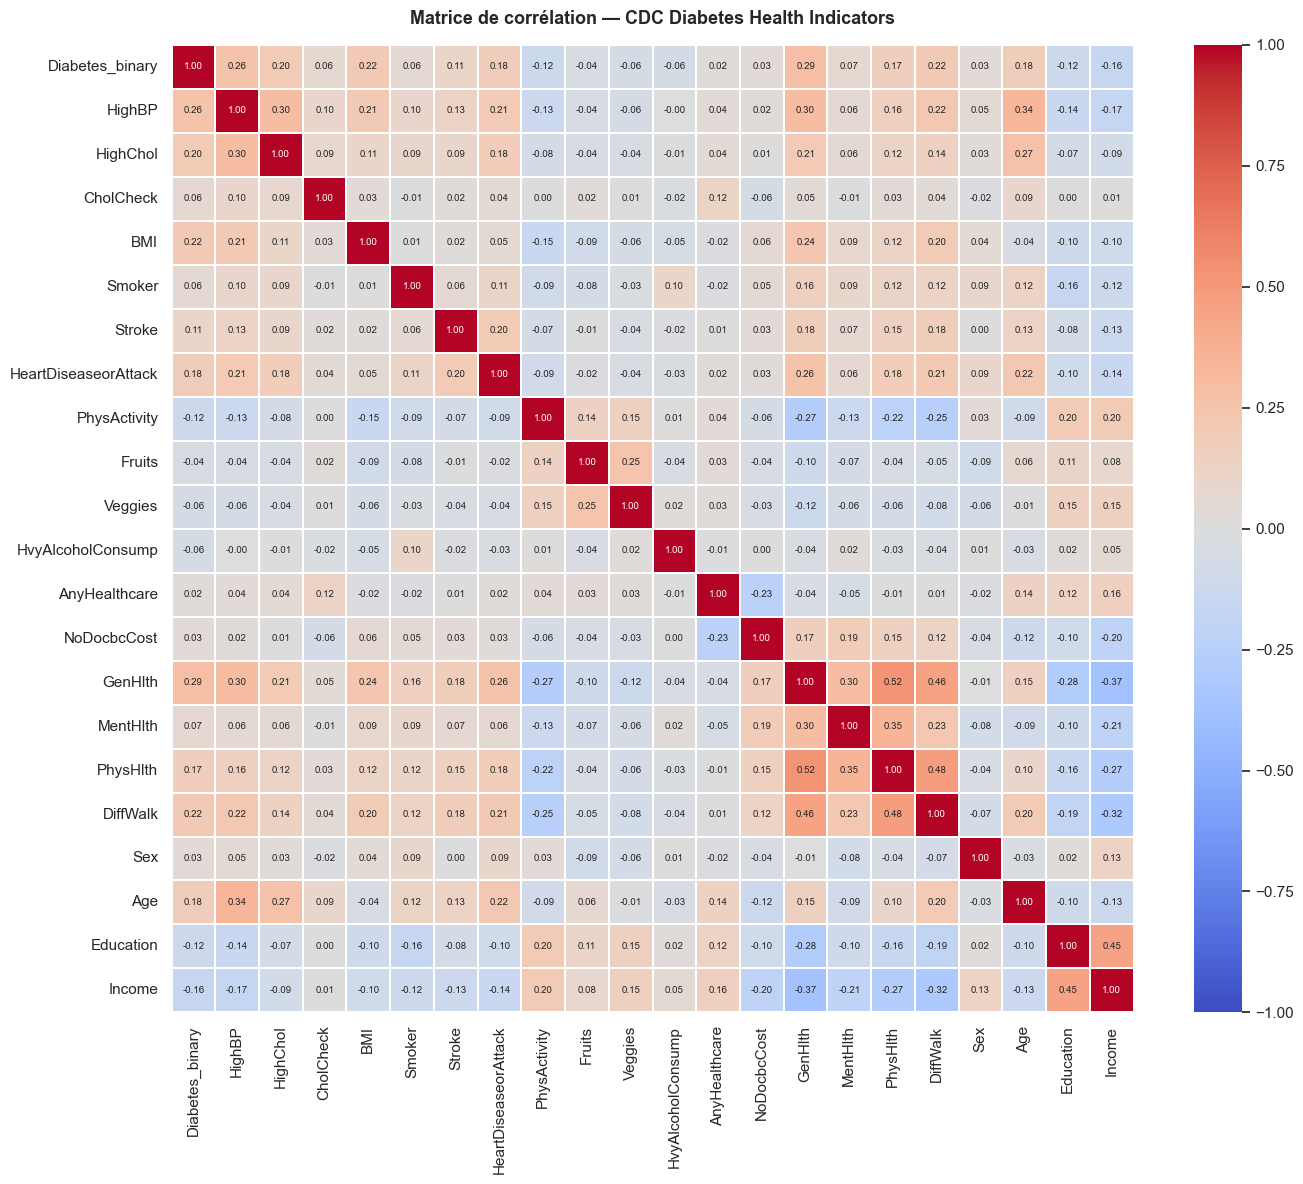

In [9]:
# Heatmap complète
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Matrice de corrélation — CDC Diabetes Health Indicators',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../../../data/processed/correlation_heatmap_cdc.png', dpi=150, bbox_inches='tight')
print('Heatmap sauvegardée → data/processed/correlation_heatmap_cdc.png')
plt.show()

---
## Section 4 — Distribution du BMI par classe

C:\Users\salma\AppData\Local\Temp\ipykernel_24520\4071796540.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_box, patch_artist=True, labels=['Non-diabétique', 'Diabétique'],


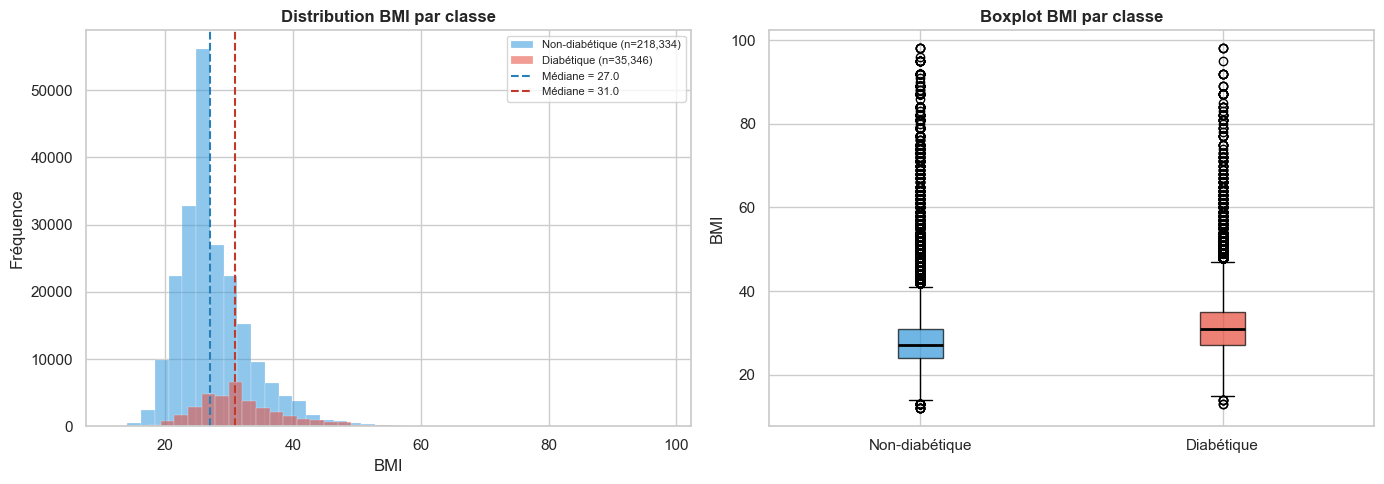

=== STATS BMI PAR CLASSE ===
                  mean  median   std
Diabetes_binary                     
0.0              27.81    27.0  6.29
1.0              31.94    31.0  7.36


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme superposé
ax = axes[0]
for outcome, color, label in [(0, '#3498db', 'Non-diabétique'), (1, '#e74c3c', 'Diabétique')]:
    subset = df[df['Diabetes_binary'] == outcome]['BMI']
    ax.hist(subset, bins=40, alpha=0.55, color=color, label=f'{label} (n={len(subset):,})',
            edgecolor='white', linewidth=0.3)

ax.set_title('Distribution BMI par classe', fontsize=12, fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Fréquence')
ax.legend()

# Ajout des médianes
for outcome, color in [(0, '#2980b9'), (1, '#c0392b')]:
    med = df[df['Diabetes_binary'] == outcome]['BMI'].median()
    ax.axvline(med, color=color, linestyle='--', linewidth=1.5, label=f'Médiane = {med:.1f}')
ax.legend(fontsize=8)

# Boxplot
ax2 = axes[1]
data_box = [
    df[df['Diabetes_binary'] == 0]['BMI'].values,
    df[df['Diabetes_binary'] == 1]['BMI'].values
]
bp = ax2.boxplot(data_box, patch_artist=True, labels=['Non-diabétique', 'Diabétique'],
                 medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#3498db'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#e74c3c'); bp['boxes'][1].set_alpha(0.7)
ax2.set_title('Boxplot BMI par classe', fontsize=12, fontweight='bold')
ax2.set_ylabel('BMI')

plt.tight_layout()
plt.show()

print('=== STATS BMI PAR CLASSE ===')
print(df.groupby('Diabetes_binary')['BMI'].agg(['mean', 'median', 'std']).round(2))

---
## Section 5 — Déséquilibre des classes

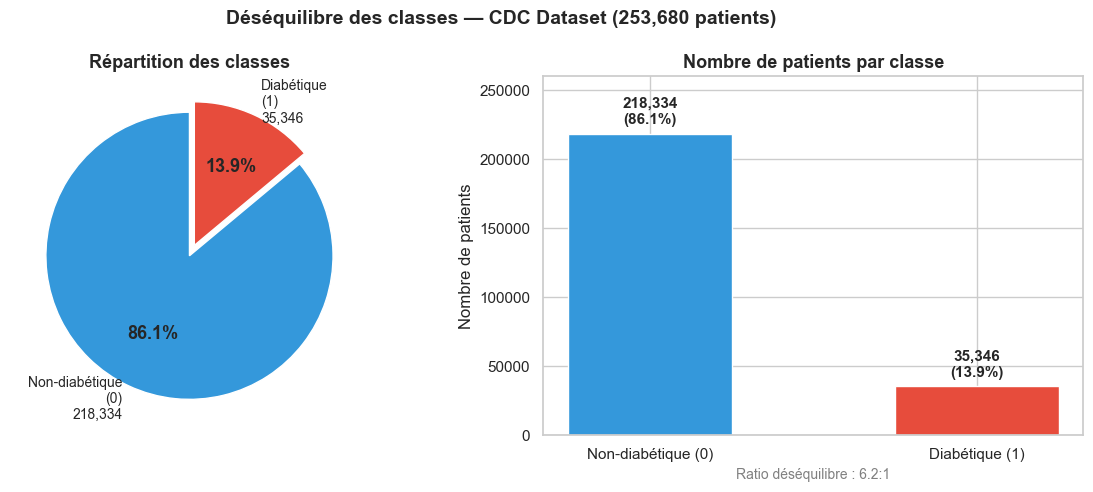


Ratio Non-diabétique / Diabétique : 6.18:1
→ Déséquilibre fort (~6:1) — stratégie de rééquilibrage nécessaire

Options recommandées :
  1. SMOTE sur X_train uniquement (surech. minorité jusqu'à 50/50)
  2. class_weight="balanced" dans les modèles sklearn
  3. scale_pos_weight=6.2 pour XGBoost
  4. Seuil de décision ajusté (threshold tuning)


In [11]:
counts = df['Diabetes_binary'].value_counts()
total = len(df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
labels_pie = [f'Non-diabétique\n(0)\n{counts[0]:,}', f'Diabétique\n(1)\n{counts[1]:,}']
wedges, texts, autotexts = ax1.pie(
    counts, labels=labels_pie, autopct='%1.1f%%',
    colors=['#3498db', '#e74c3c'], explode=(0, 0.08),
    startangle=90, textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(13); at.set_fontweight('bold')
ax1.set_title('Répartition des classes', fontsize=13, fontweight='bold')

# Bar chart
bars = ax2.bar(
    ['Non-diabétique (0)', 'Diabétique (1)'],
    counts.values,
    color=['#3498db', '#e74c3c'],
    width=0.5, edgecolor='white'
)
ax2.bar_label(bars,
    labels=[f'{v:,}\n({v/total*100:.1f}%)' for v in counts.values],
    padding=5, fontsize=11, fontweight='bold'
)
ax2.set_title('Nombre de patients par classe', fontsize=13, fontweight='bold')
ax2.set_ylabel('Nombre de patients')
ax2.set_ylim(0, 260000)

ratio = counts[0] / counts[1]
ax2.set_xlabel(f'Ratio déséquilibre : {ratio:.1f}:1', fontsize=10, color='gray')

fig.suptitle(f'Déséquilibre des classes — CDC Dataset ({total:,} patients)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nRatio Non-diabétique / Diabétique : {ratio:.2f}:1')
print(f'→ Déséquilibre fort (~6:1) — stratégie de rééquilibrage nécessaire')
print(f'\nOptions recommandées :')
print(f'  1. SMOTE sur X_train uniquement (surech. minorité jusqu\'à 50/50)')
print(f'  2. class_weight="balanced" dans les modèles sklearn')
print(f'  3. scale_pos_weight={ratio:.1f} pour XGBoost')
print(f'  4. Seuil de décision ajusté (threshold tuning)')